In [23]:
pip install PyExifTool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 962.6 kB/s eta 0:00:00eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [28]:
import exiftool
from pathlib import Path
import json
# Example file
file_path = Path("/mnt/ssd2tb/boat/thesis/s21fe_dataset/raw/low-light/20240124_151032.dng")  # can be .dng, .cr2, .nef, etc.

with exiftool.ExifTool() as et:
    # print(dir(et))
    # print(et.execute_json(str(file_path)))
    metadata = et.execute(str(file_path))
    print(metadata)
    metadata = et.get_metadata(str(file_path))

[ExifTool]      ExifTool Version Number         : 12.40
[File]          File Name                       : 20240124_151032.dng
[File]          Directory                       : /mnt/ssd2tb/boat/thesis/s21fe_dataset/raw/low-light
[File]          File Size                       : 24311849
[File]          File Modification Date/Time     : 2024:01:24 15:10:32+07:00
[File]          File Access Date/Time           : 2025:06:06 10:57:57+07:00
[File]          File Inode Change Date/Time     : 2025:03:26 16:08:42+07:00
[File]          File Permissions                : 100740
[File]          File Type                       : DNG
[File]          File Type Extension             : DNG
[File]          MIME Type                       : image/x-adobe-dng
[File]          Exif Byte Order                 : II
[EXIF]          Image Width                     : 4000
[EXIF]          Image Height                    : 3000
[EXIF]          Bits Per Sample                 : 16
[EXIF]          Compression         

AttributeError: 'ExifTool' object has no attribute 'get_metadata'

sl: found 168 files from pattern /mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/sl_*/*.dng
ll: found 162 files from pattern /mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/ll_*/*.dng

Processing sl (168 files)
Extracted 168 ISO values

Processing ll (162 files)
Extracted 162 ISO values


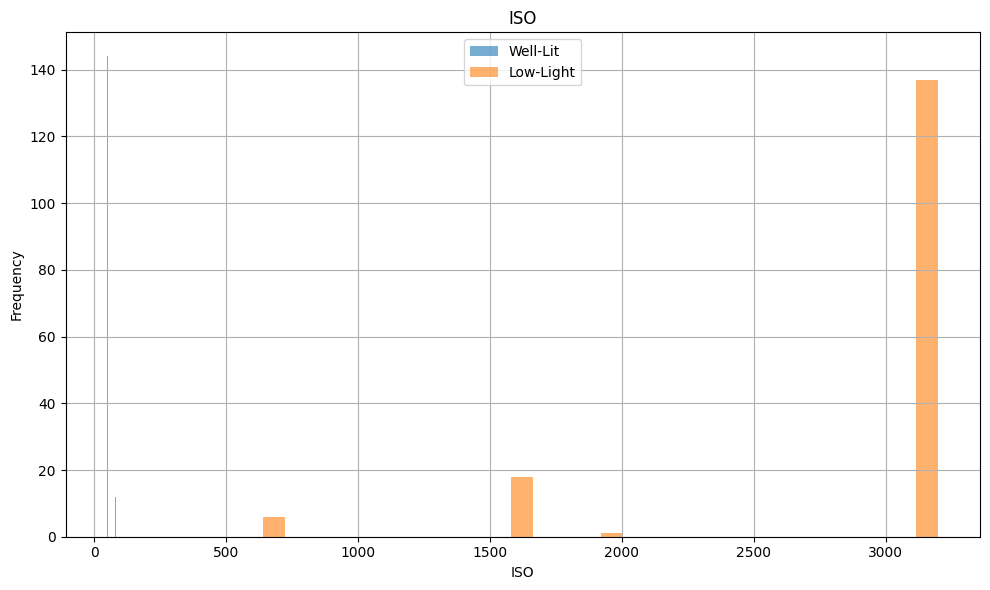

In [19]:
import exiftool
from pathlib import Path
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
import re

RAW_EXTENSIONS = {
    '.cr2', '.nef', '.arw', '.dng',
    '.rw2', '.orf', '.raf', '.srw', '.pef'
}


def is_raw_file(p: Path):
    return p.suffix.lower() in RAW_EXTENSIONS


def parse_exiftool_output(output_str):
    data = {}

    for line in output_str.splitlines():
        match = re.match(r'^\[.*?\]\s+(.+?)\s+:\s(.+)$', line)

        if match:
            key = match.group(1).strip()
            value = match.group(2).strip()
            data[key] = value

    return data


def extract_metadata_values(file_paths, target_key, et):
    values = []

    for p in file_paths:
        try:
            metadata = parse_exiftool_output(
                et.execute(str(p))
            )

            if target_key in metadata:
                try:
                    values.append(float(metadata[target_key]))
                except ValueError:
                    pass

        except Exception as e:
            print(f"Failed: {p}")
            print(e)

    return values


def pattern_to_label(pattern):
    """
    Example:

    sl_*/*.dng      -> sl
    wl_*/*.dng      -> wl
    indoor_*/*.dng  -> indoor
    """

    folder = Path(pattern).parent.name

    if "*" in folder:
        folder = folder.split("*")[0]

    return folder.rstrip("_-. ")


def collect_files_by_pattern(patterns):
    grouped_files = defaultdict(list)

    for pattern in patterns:
        label = pattern_to_label(pattern)

        matches = glob(pattern, recursive=True)

        matches = [
            Path(m)
            for m in matches
            if Path(m).is_file()
            and is_raw_file(Path(m))
        ]

        grouped_files[label].extend(matches)

        print(
            f"{label}: found {len(matches)} files "
            f"from pattern {pattern}"
        )

    return grouped_files


def plot_histograms(data_dict, target_key, legend_names=None):
    plt.figure(figsize=(10, 6))

    for label, values in data_dict.items():
        if len(values) == 0:
            continue

        display_label = (
            legend_names.get(label, label)
            if legend_names is not None
            else label
        )

        plt.hist(
            values,
            bins=30,
            alpha=0.6,
            label=f"{display_label}"
        )

    plt.title(target_key)

    xlabel = target_key
    if target_key == "Shutter Speed":
        xlabel += " (Second)"

    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def main(
    patterns,
    target_key="ISO",
    legend_names=None
):
    grouped_files = collect_files_by_pattern(patterns)

    data_by_group = {}

    with exiftool.ExifTool() as et:

        for label, files in grouped_files.items():

            print(
                f"\nProcessing {label} "
                f"({len(files)} files)"
            )

            values = extract_metadata_values(
                files,
                target_key,
                et
            )

            data_by_group[label] = values

            print(
                f"Extracted {len(values)} "
                f"{target_key} values"
            )

    plot_histograms(
        data_by_group,
        target_key,
        legend_names=legend_names
    )


# ==================================================
# Example
# ==================================================
patterns = [
    "/mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/sl_*/*.dng",
    "/mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/ll_*/*.dng",
]

legend_names = {
    "sl": "Well-Lit",
    "ll": "Low-Light",
}

main(
    patterns,
    target_key="ISO",
    legend_names=legend_names
)

In [2]:
image.white_level

NameError: name 'image' is not defined

sl: found 168 files from pattern /mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/sl_*/*.dng
ll: found 162 files from pattern /mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/ll_*/*.dng

Processing Well-Lit (168 files)
Extracted 168 white-balance vectors

Processing Low-Light (162 files)
Extracted 162 white-balance vectors

Running TSNE on 330 samples...


/tmp/ipykernel_68776/43596406.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


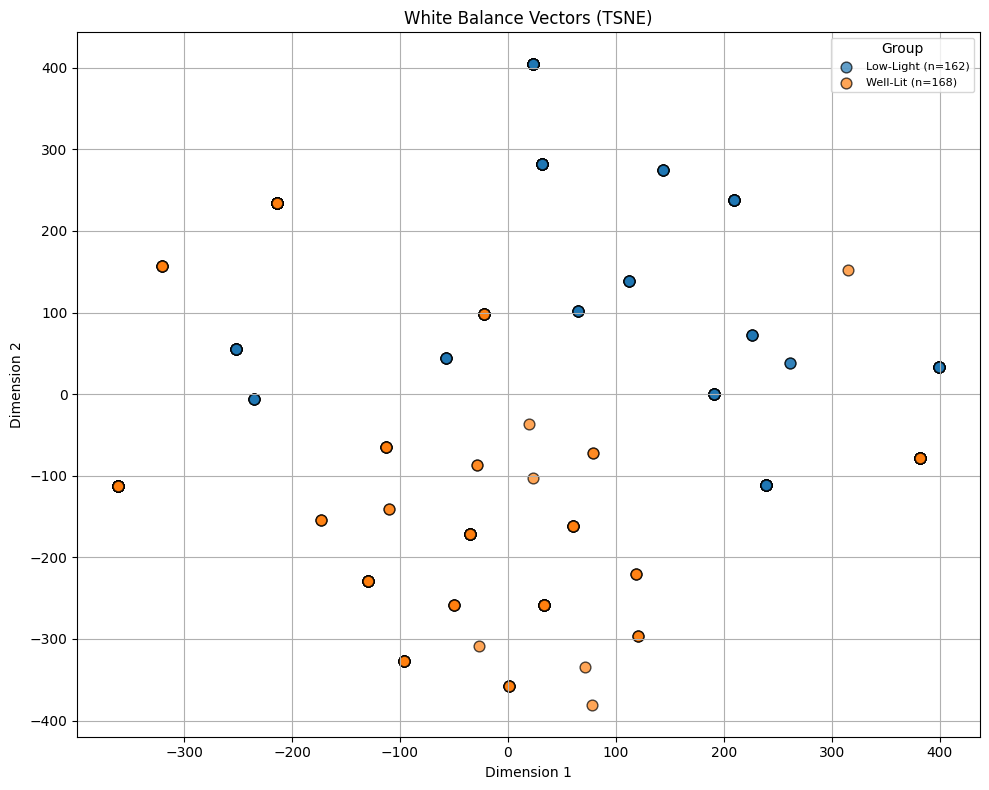

In [20]:
import rawpy
import numpy as np
from pathlib import Path
from glob import glob
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

RAW_EXTENSIONS = {
    '.cr2', '.nef', '.arw', '.dng',
    '.rw2', '.orf', '.raf', '.srw', '.pef'
}


# ============================================================
# File utilities
# ============================================================

def is_raw_file(path: Path):
    return path.suffix.lower() in RAW_EXTENSIONS


def pattern_to_label(pattern):
    """
    Examples
    --------
    sl_*/*.dng      -> sl
    ll_*/*.dng      -> ll
    indoor_*/*.dng  -> indoor
    """

    folder = Path(pattern).parent.name

    if "*" in folder:
        folder = folder.split("*")[0]

    return folder.rstrip("_-. ")


def collect_files_by_pattern(patterns):
    grouped_files = defaultdict(list)

    for pattern in patterns:

        label = pattern_to_label(pattern)

        matches = [
            Path(p)
            for p in glob(pattern, recursive=True)
            if Path(p).is_file()
            and is_raw_file(Path(p))
        ]

        grouped_files[label].extend(matches)

        print(
            f"{label}: found {len(matches)} files "
            f"from pattern {pattern}"
        )

    return grouped_files


# ============================================================
# White balance extraction
# ============================================================

def extract_white_balance_vector(file_path: Path):
    try:
        with rawpy.imread(str(file_path)) as raw:

            cam_mul = np.array(
                raw.camera_whitebalance,
                dtype=np.float32
            )

            if (
                cam_mul is None
                or np.any(np.isnan(cam_mul))
            ):
                cam_mul = np.array(
                    raw.daylight_whitebalance,
                    dtype=np.float32
                )

            return cam_mul

    except Exception as e:
        print(
            f"Error reading {file_path.name}: {e}"
        )
        return None


# ============================================================
# Visualization
# ============================================================

def reduce_and_plot(
    vectors,
    labels,
    method="tsne"
):
    if method.lower() == "tsne":

        n_samples = len(vectors)

        perplexity = min(
            30,
            max(2, n_samples // 10)
        )

        reducer = TSNE(
            n_components=2,
            random_state=42,
            perplexity=perplexity
        )

    elif method.lower() == "pca":

        reducer = PCA(
            n_components=2
        )

    else:
        raise ValueError(
            "method must be 'tsne' or 'pca'"
        )

    embeddings = reducer.fit_transform(
        vectors
    )

    unique_labels = sorted(
        set(labels)
    )

    cmap = get_cmap("tab10")

    color_map = {
        label: cmap(i % 10)
        for i, label in enumerate(
            unique_labels
        )
    }

    plt.figure(figsize=(10, 8))

    for label in unique_labels:

        idxs = [
            i
            for i, l in enumerate(labels)
            if l == label
        ]

        plt.scatter(
            embeddings[idxs, 0],
            embeddings[idxs, 1],
            label=f"{label} (n={len(idxs)})",
            color=color_map[label],
            edgecolors="k",
            alpha=0.7,
            s=60
        )

    plt.title(
        f"White Balance Vectors "
        f"({method.upper()})"
    )

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")

    plt.legend(
        title="Group",
        loc="best",
        fontsize=8
    )

    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ============================================================
# Main pipeline
# ============================================================

def main(
    patterns,
    legend_names=None,
    method="tsne"
):
    grouped_files = collect_files_by_pattern(
        patterns
    )

    vectors = []
    labels = []

    for label, files in grouped_files.items():

        display_label = (
            legend_names.get(label, label)
            if legend_names is not None
            else label
        )

        print(
            f"\nProcessing "
            f"{display_label} "
            f"({len(files)} files)"
        )

        valid_count = 0

        for file_path in files:

            wb = extract_white_balance_vector(
                file_path
            )

            if wb is not None:

                vectors.append(wb)
                labels.append(
                    display_label
                )

                valid_count += 1

        print(
            f"Extracted "
            f"{valid_count} "
            f"white-balance vectors"
        )

    if len(vectors) == 0:

        print(
            "No valid white balance "
            "vectors found."
        )

        return

    vectors = np.stack(vectors)

    print(
        f"\nRunning {method.upper()} "
        f"on {len(vectors)} samples..."
    )

    reduce_and_plot(
        vectors,
        labels,
        method=method
    )


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":

    patterns = [
        "/mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/sl_*/*.dng",
        "/mnt/ssd2tb/boat/thesis/s21fe_hpatches_v4.1/ll_*/*.dng",
    ]

    legend_names = {
        "sl": "Well-Lit",
        "ll": "Low-Light",
    }

    main(
        patterns,
        legend_names=legend_names,
        method="tsne"   # or "pca"
    )